In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Initial Overview

In [2]:
df = pd.read_csv('../data/mountain_dataset.csv', converters={'marker': ast.literal_eval})

In [3]:
print("Dataset Shape:", df.shape)
print("-" * 40)
df.info()

Dataset Shape: (1584, 2)
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1584 non-null   str   
 1   marker  1584 non-null   object
dtypes: object(1), str(1)
memory usage: 24.9+ KB


In [4]:
df.head()

,text,marker
0,A visit to a science museum for hands-on learn...,[]
1,Voice surface coach set democratic time year. ...,[]
2,Parent according maybe activity activity finis...,[]
3,A visit to a sculpture garden with intriguing ...,[]
4,The Julian Alps in Slovenia offer pristine lak...,"[(11, 15)]"


In [5]:
df['mountain_count'] = df['marker'].apply(len)

df['contains_mountain'] = df['mountain_count'] > 0

print(df['contains_mountain'].value_counts())
print("-" * 40)
print(df['contains_mountain'].value_counts(normalize=True) * 100)

contains_mountain
False    1358
True      226
Name: count, dtype: int64
----------------------------------------
contains_mountain
False    85.732323
True     14.267677
Name: proportion, dtype: float64


## The Class Imbalance Problem

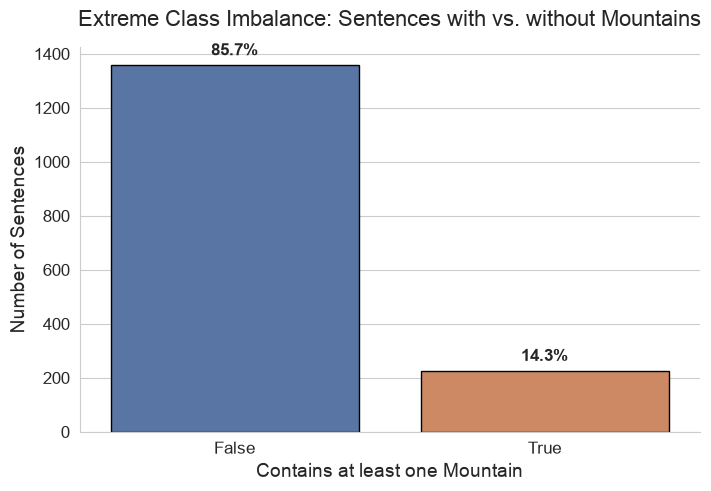

In [14]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df, 
    x='contains_mountain', 
    hue='contains_mountain', 
    palette='deep', 
    edgecolor='black',
    legend=False
)

plt.title("Extreme Class Imbalance: Sentences with vs. without Mountains", fontsize=16, pad=15)
plt.xlabel("Contains at least one Mountain", fontsize=14)
plt.ylabel("Number of Sentences", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove the top and right borders for a cleaner aesthetic
sns.despine()

# Add percentages on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.015) 
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

## Sequence Length Analysis

In [15]:
# Calculate character length and approximate word length
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

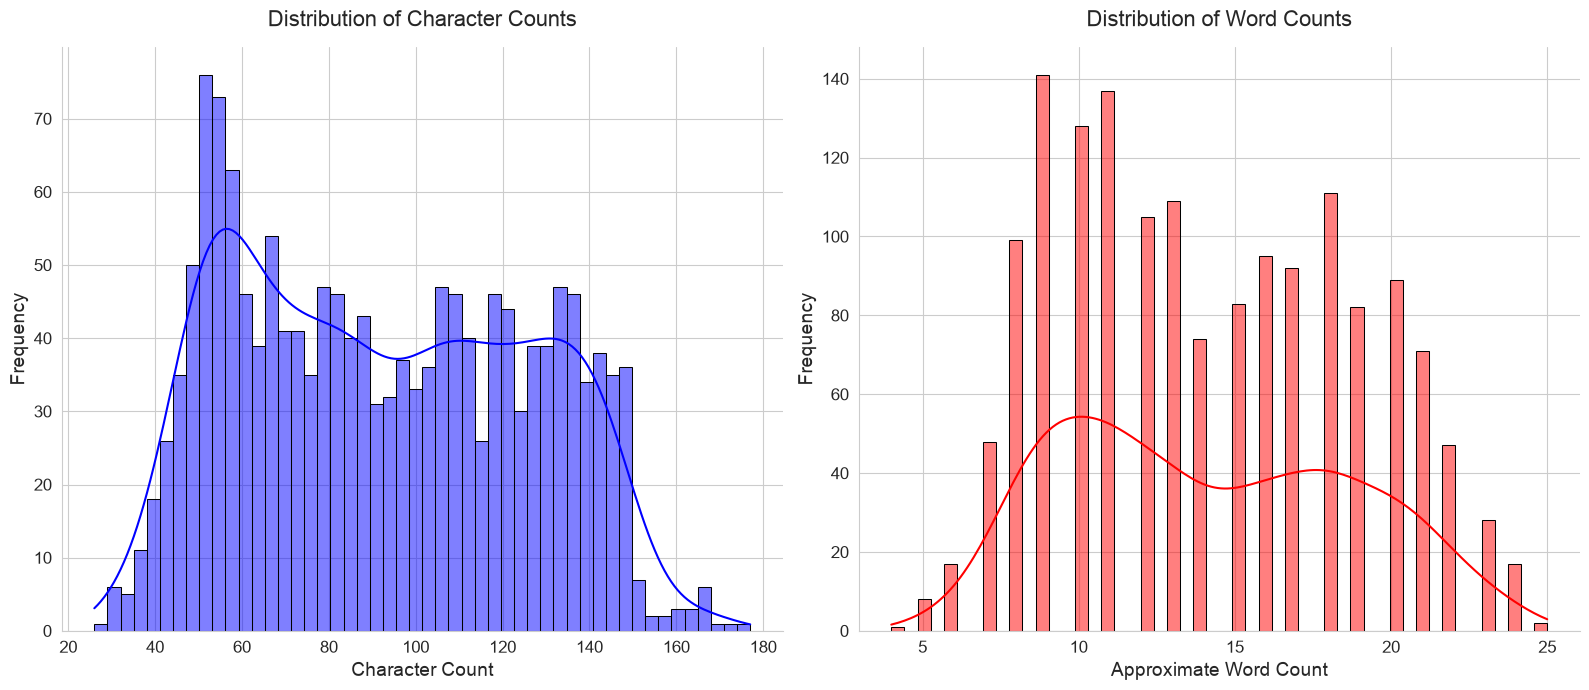

Max word count in a single sentence: 25
NER models like DistilBERT have strict maximum token limits (usually 512).


In [18]:
plt.figure(figsize=(16, 7))

# Plot Character Count
plt.subplot(1, 2, 1)
sns.histplot(df['char_length'], bins=50, kde=True, color='blue', edgecolor='black')
plt.title("Distribution of Character Counts", fontsize=16, pad=15)
plt.xlabel("Character Count", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

# Plot Word Count
plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=50, kde=True, color='red', edgecolor='black')
plt.title("Distribution of Word Counts", fontsize=16, pad=15)
plt.xlabel("Approximate Word Count", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

print(f"Max word count in a single sentence: {df['word_count'].max()}")
print("NER models like DistilBERT have strict maximum token limits (usually 512).")

## Entity Extraction & Frequency Analysis

In [19]:
def extract_full_entities(row):
    """
    Extracts the exact substring from the text using the character indices.
    """
    text = row['text']
    markers = row['marker']
    
    entities = []
    for start, end in markers:
        entities.append(text[start:end])
        
    return entities

In [20]:
df['extracted_mountains'] = df.apply(extract_full_entities, axis=1)

all_mountains = [mountain for sublist in df['extracted_mountains'].tolist() for mountain in sublist]

# Calculate frequencies
mountain_freq = pd.Series(all_mountains).value_counts()

print(f"Total unique mountains: {len(mountain_freq)}")
print("-" * 40)
print("Top 15 Most Frequent Mountains:")
print(mountain_freq.head(15))

Total unique mountains: 41
----------------------------------------
Top 15 Most Frequent Mountains:
Alps                      34
Andes                     19
Himalayas                 19
Taurus Mountains          12
Mount Everest              9
Rhodope Mountains          9
Appalachian Mountains      8
Rocky Mountains            8
Mount Fuji                 7
Mount Kilimanjaro          7
Scandinavian Mountains     7
Kunlun Mountains           5
Denali                     5
Mount Rainier              5
Mount Olympus              5
Name: count, dtype: int64


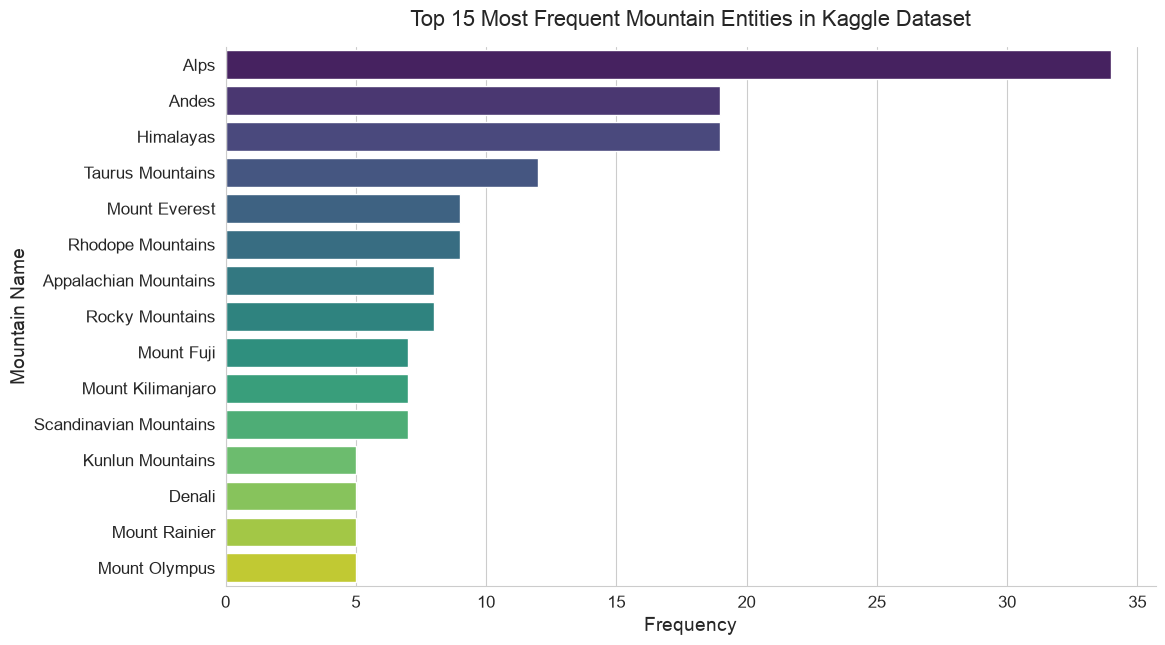

In [21]:
# Visualize the Top 15
plt.figure(figsize=(12, 7))

sns.barplot(
    x=mountain_freq.head(15).values, 
    y=mountain_freq.head(15).index, 
    hue=mountain_freq.head(15).index,
    palette='viridis',
    legend=False
)

plt.title("Top 15 Most Frequent Mountain Entities in Kaggle Dataset", fontsize=16, pad=15)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Mountain Name", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove borders
sns.despine()

plt.show()